In [1]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [ ]:


# Function to compute histograms for an image
def compute_histograms(image, color_space='HSV'):
    if color_space == 'HSV':
        image = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
        channels = ('H', 'S', 'V')
    elif color_space == 'LAB':
        image = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
        channels = ('L', 'A', 'B')

    histograms = {}
    for i, channel in enumerate(channels):
        hist = cv2.calcHist([image], [i], None, [256], [0, 256])
        histograms[channel] = hist

    return histograms

# Function to compute brightness and contrast
def compute_brightness_contrast(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    brightness = np.mean(gray)
    contrast = np.std(gray)
    return brightness, contrast

# Function to find dominant colors
def find_dominant_colors(image, k=3):
    pixels = image.reshape(-1, 3)
    kmeans = KMeans(n_clusters=k, n_init=10)  # Explicitly set n_init to 10
    kmeans.fit(pixels)
    colors = kmeans.cluster_centers_
    return colors
# Path to the ISIC 2017 dataset
dataset_path = '../dataset/train/images'

# Initialize aggregators for the entire dataset
brightness_values = []
contrast_values = []
overall_histograms = {'H': np.zeros((256, 1)), 'S': np.zeros((256, 1)), 'V': np.zeros((256, 1))}
dominant_colors_all = []

# Iterate through all images in the dataset
for image_name in os.listdir(dataset_path):
    if image_name.endswith('.png'):
        image_path = os.path.join(dataset_path, image_name)
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB
    
        # Compute histograms for the image
        histograms = compute_histograms(image, color_space='HSV')
        for channel in overall_histograms.keys():
            overall_histograms[channel] += histograms[channel]
    
        # Compute brightness and contrast
        brightness, contrast = compute_brightness_contrast(image)
        brightness_values.append(brightness)
        contrast_values.append(contrast)
    
        # Compute dominant colors
        dominant_colors = find_dominant_colors(image, k=3)
        dominant_colors_all.append(dominant_colors)

# Normalize histograms by the number of images
num_images = len(os.listdir(dataset_path))
for channel in overall_histograms.keys():
    overall_histograms[channel] /= num_images

# Plot overall histograms
def plot_overall_histograms(overall_histograms):
    for channel, hist in overall_histograms.items():
        plt.plot(hist, label=channel)
    plt.title("Overall Color Distribution")
    plt.legend()
    plt.show()

# Plot brightness and contrast distribution
def plot_brightness_contrast(brightness_values, contrast_values):
    plt.figure()
    plt.hist(brightness_values, bins=50, alpha=0.5, label='Brightness')
    plt.hist(contrast_values, bins=50, alpha=0.5, label='Contrast')
    plt.title("Brightness and Contrast Distribution")
    plt.legend()
    plt.show()

# Execute plotting functions
plot_overall_histograms(overall_histograms)
plot_brightness_contrast(brightness_values, contrast_values)

# Analyze dominant colors
def plot_dominant_colors(dominant_colors_all):
    # Flatten list of dominant colors and reshape for plotting
    all_colors = np.vstack(dominant_colors_all)
    plt.figure(figsize=(10, 5))
    plt.imshow([all_colors.astype(np.uint8)], aspect='auto')
    plt.title("Dominant Colors Across Dataset")
    plt.show()

plot_dominant_colors(dominant_colors_all)


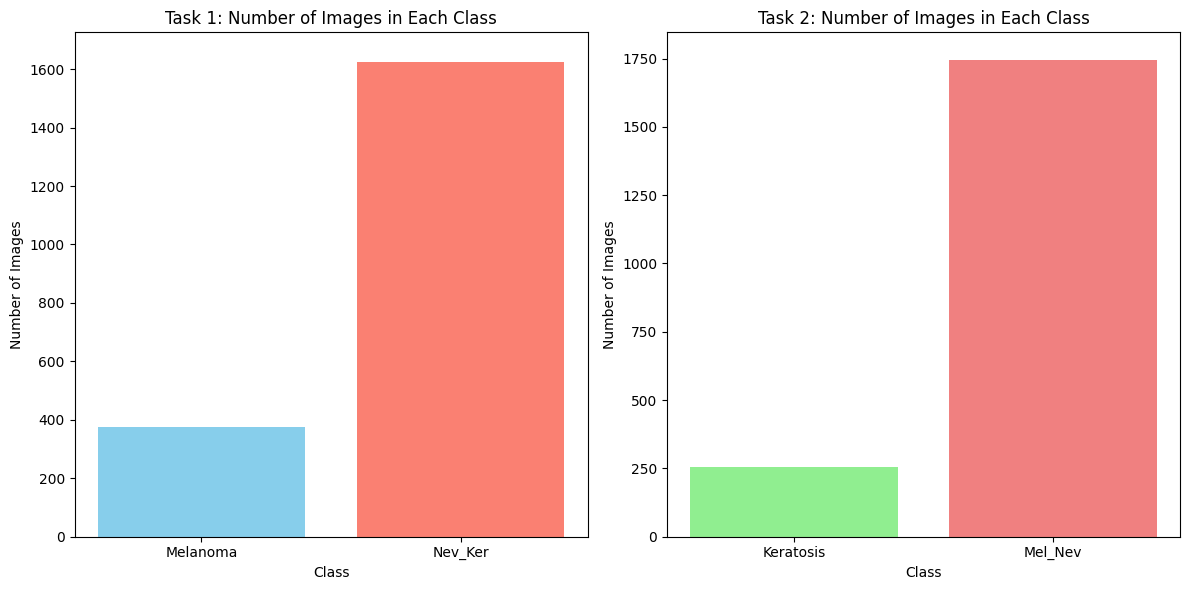

In [1]:
import matplotlib.pyplot as plt

# Data for Task 1
task1_classes = ['Melanoma', 'Nev_Ker']
task1_counts = [374, 1626]

# Data for Task 2
task2_classes = ['Keratosis', 'Mel_Nev']
task2_counts = [254, 1746]

# Create a figure and axis for the plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot for Task 1
ax1.bar(task1_classes, task1_counts, color=['skyblue', 'salmon'])
ax1.set_title('Task 1: Number of Images in Each Class')
ax1.set_xlabel('Class')
ax1.set_ylabel('Number of Images')
ax1.set_ylim(0, max(task1_counts) + 100)  # Adjust y-axis for better visualization

# Plot for Task 2
ax2.bar(task2_classes, task2_counts, color=['lightgreen', 'lightcoral'])
ax2.set_title('Task 2: Number of Images in Each Class')
ax2.set_xlabel('Class')
ax2.set_ylabel('Number of Images')
ax2.set_ylim(0, max(task2_counts) + 100)  # Adjust y-axis for better visualization

# Improve layout and display the plots
plt.tight_layout()
plt.show()
